# Extreme Streamflow Prediction Using Temporal Features

# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# 2. Load Dataset

In [ ]:
#Load as a CSV file
uploaded = files.upload()


file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

Saving ML_streamflow_meteorological_data.csv to ML_streamflow_meteorological_data.csv


,Date,Streamflow,Precipitation,Temperature
0,1962-01-01,8.74,0.0,10.1
1,1962-01-02,6.35,0.0,10.2
2,1962-01-03,5.45,0.0,13.5
3,1962-01-04,5.09,0.0,10.2
4,1962-01-05,4.73,1.0,6.9


In [ ]:
df.describe()

,Streamflow,Precipitation,Temperature
count,18536.000000,18403.000000,18388.000000
mean,8.863350,1.625420,16.474260
std,21.353546,5.434524,7.712399
min,0.000000,0.000000,-6.000000
25%,0.168000,0.000000,10.300000
50%,1.600000,0.000000,16.100000
75%,7.500000,0.000000,23.300000
max,614.000000,78.100000,34.600000


# 3. Data Preprocessing

In [ ]:
# Data Preprocessing

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18536 entries, 0 to 18535
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           18536 non-null  datetime64[ns]
 1   Streamflow     18536 non-null  float64       
 2   Precipitation  18403 non-null  float64       
 3   Temperature    18388 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 579.4 KB


# 4. Target Definition

In [ ]:
# Target Definition

threshold = df["Streamflow"].quantile(0.90)

df["target"] = (df["Streamflow"] > threshold).astype(int)

print("Threshold:", threshold)

df["target"].value_counts()

Threshold: 23.5


,count
target,
0,16687
1,1849


<Axes: xlabel='target'>

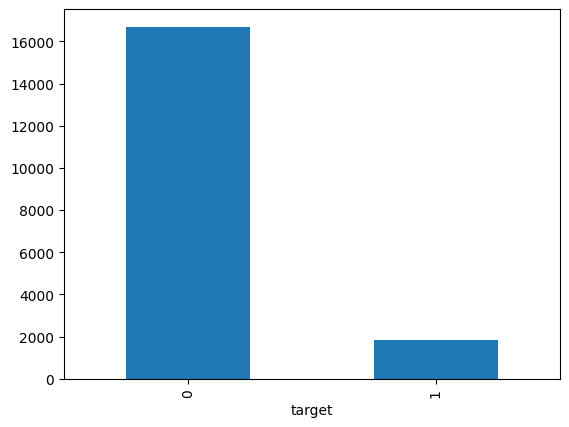

In [ ]:
#Distribution

df["target"].value_counts(normalize=True)
df["target"].value_counts().plot(kind="bar")

# 5. Feature Engineering

In [ ]:
# Feature Engineering

for lag in [1, 2, 3, 5]:

    df[f"flow_lag_{lag}"] = df["Streamflow"].shift(lag)

    df[f"precip_lag_{lag}"] = df["Precipitation"].shift(lag)

    df[f"temp_lag_{lag}"] = df["Temperature"].shift(lag)

In [ ]:
#Aggregated features

df["precip_sum_3"] = df["Precipitation"].rolling(3).sum()

df["precip_sum_5"] = df["Precipitation"].rolling(5).sum()

In [ ]:
#Drop NAN values

df = df.dropna()

df.head()

,Date,Streamflow,Precipitation,Temperature,target,flow_lag_1,precip_lag_1,temp_lag_1,flow_lag_2,precip_lag_2,temp_lag_2,flow_lag_3,precip_lag_3,temp_lag_3,flow_lag_5,precip_lag_5,temp_lag_5,precip_sum_3,precip_sum_5
5,1962-01-06,4.55,0.0,3.9,0,4.73,1.0,6.9,5.09,0.0,10.2,5.45,0.0,13.5,8.74,0.0,10.1,1.0,1.0
6,1962-01-07,4.40,0.0,4.0,0,4.55,0.0,3.9,4.73,1.0,6.9,5.09,0.0,10.2,6.35,0.0,10.2,1.0,1.0
7,1962-01-08,4.25,0.2,7.9,0,4.40,0.0,4.0,4.55,0.0,3.9,4.73,1.0,6.9,5.45,0.0,13.5,0.2,1.2
8,1962-01-09,4.25,0.0,5.8,0,4.25,0.2,7.9,4.40,0.0,4.0,4.55,0.0,3.9,5.09,0.0,10.2,0.2,1.2
9,1962-01-10,3.95,0.0,6.1,0,4.25,0.0,5.8,4.25,0.2,7.9,4.40,0.0,4.0,4.73,1.0,6.9,0.2,0.2


# 6. Train-Test Split

In [ ]:
# Train-Test Split

train_size = int(len(df) * 0.7)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

In [ ]:
#Feature List

features = [col for col in df.columns if "lag" in col or "sum" in col]

print(features)

['flow_lag_1', 'precip_lag_1', 'temp_lag_1', 'flow_lag_2', 'precip_lag_2', 'temp_lag_2', 'flow_lag_3', 'precip_lag_3', 'temp_lag_3', 'flow_lag_5', 'precip_lag_5', 'temp_lag_5', 'precip_sum_3', 'precip_sum_5']


In [ ]:
#X ve y

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

# 7. Baseline Model

## 7.1. Baseline Model: Logistic Regression

### 7.1.1. Implemention of Logistic Regression

In [ ]:
# Logistic Regression

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [ ]:
lr_preds = lr_model.predict(X_test)

### 7.1.2. Model Evaluation of Logistic Regression




In [ ]:
# Model Evaluation of Logistic Regression

# Train Performance

lr_train_preds = lr_model.predict(X_train)

print(classification_report(y_train, lr_train_preds))
print("Recall:", recall_score(y_train, lr_train_preds))
print("F1 Score:", f1_score(y_train, lr_train_preds))


              precision    recall  f1-score   support

           0       1.00      0.97      0.98     11289
           1       0.82      0.98      0.89      1553

    accuracy                           0.97     12842
   macro avg       0.91      0.97      0.94     12842
weighted avg       0.97      0.97      0.97     12842

Recall: 0.9755312298776562
F1 Score: 0.8890845070422535


In [ ]:
# Test Performance

print(classification_report(y_test, lr_preds))
print("Recall:", recall_score(y_test,lr_preds))
print("F1 Score:", f1_score(y_test, lr_preds))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99      5209
           1       0.68      0.98      0.81       296

    accuracy                           0.97      5505
   macro avg       0.84      0.98      0.90      5505
weighted avg       0.98      0.97      0.98      5505

Recall: 0.9763513513513513
F1 Score: 0.8050139275766016


## 7.2. Baseline Model: Random Forest

### 7.2.1. Implemention of Random Forest

In [ ]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
rf_preds = rf_model.predict(X_test)

### 7.2.2. Model Evaluation of Random Forest

In [ ]:
# Model Evaluation of Random Forest

# Train Performance

rf_train_preds = rf_model.predict(X_train)

print(classification_report(y_train, rf_train_preds))
print("Recall:", recall_score(y_train, rf_train_preds))
print("F1 Score:", f1_score(y_train, rf_train_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11289
           1       1.00      1.00      1.00      1553

    accuracy                           1.00     12842
   macro avg       1.00      1.00      1.00     12842
weighted avg       1.00      1.00      1.00     12842

Recall: 1.0
F1 Score: 1.0


In [ ]:
# Test Performance

print(classification_report(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1 Score:", f1_score(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5209
           1       0.88      0.80      0.84       296

    accuracy                           0.98      5505
   macro avg       0.94      0.90      0.92      5505
weighted avg       0.98      0.98      0.98      5505

Recall: 0.8006756756756757
F1 Score: 0.8404255319148937


## 7.3. Results

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Status": [
        "Implemented",
        "Implemented"
    ],

    "Notes": [
        "Initial baseline with lag and aggregated features",
        "Tree-based baseline with lag and aggregated features"
    ]
})

results

,Model,Status,Notes
0,Logistic Regression,Implemented,Initial baseline with lag and aggregated features
1,Random Forest,Implemented,Tree-based baseline with lag and aggregated fe...


# 9. Initial Observations and Future Work

Initial experiments indicate that lag-based temporal features contain useful predictive information for identifying extreme streamflow events. Logistic Regression demonstrated strong Recall performance and relatively stable generalization behavior, while Random Forest achieved higher F1-score performance but showed signs of overfitting.

Future work will focus on:
- testing additional boosting-based models such as XGBoost and LightGBM,
- comparing different temporal lookback windows,
- conducting ablation studies for temporal feature configurations,
- analyzing feature importance and model interpretability,
- and improving robustness for rare-event prediction.